У официальномго сайта Yahoo finance (https://finance.yahoo.com/) отсутствует официальный api, при этом у неофициального yfinance, который является python библиотекой, нет официальной документации на эндпоинты. Поэтому данные о котировках мы решили парсить самостоятельно вручную.

Изначально мы попробовали сделать это так же с использованием библиотек requests и bs4, но yahoo finance блокируют парсинг своего сайта и при первой же попытке get, сайт выдает response 429 - too many requests. 

In [1]:
import requests

In [2]:
url = 'https://finance.yahoo.com/quote/AAPL/history/'
page = requests.get(url)
page

<Response [429]>

Поэтому мы использовали библиотеку Selenuim, которая имитирует человеческое поведение, тем самым обходя блокировку парсинга.

Будем рассмотривать 8 иностранных компаний из разных отраслей, чтобы наш анализ был более обширным. Мы выбрали монополистов крупных сфер: Apple (технологии), Exxon Mobil (энергетика), Tesla (автопром), Walmart (ритейл), Pfizer (медицина), Netflix (медиа), JPMorgan (финансы), Caterpillar (индустрия).

Импортируем все библиотеки

In [ ]:

import time
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from datetime import datetime
import pandas as pd
import numpy as np


Мы будем рассматривать период с 01.01.2021-09.04.2026, выпишем тикеры выбранных компаний (AAPL, XOM, TSLA, WMT, PFE, NFLX, JPM, CAT)

In [ ]:
startdate = datetime(2021, 1, 1).timestamp()
enddate = datetime(2026, 4, 9).timestamp()

При загрузке сайта появляется соглашение cookie файлов, поэтому через click() закрываем уведомление.

In [ ]:
service = Service(ChromeDriverManager().install())
driver = webdriver.Chrome(service=service)

url = f'https://finance.yahoo.com/quote/{ticker}/history/?period1={startdate}&period2={enddate}'
driver.get(url)

try:
    accept = WebDriverWait(driver, 3).until(EC.element_to_be_clickable((By.XPATH, "//button[contains(text(), 'Accept all')]")))
    accept.click()
except:
    pass

Затем возьмем шапку таблицы у компании Apple (она у всех компаний одинаковая, просто, чтобы данные добавлялись без дополнительных строчек). Извлекаем заголовки со страницы.

In [ ]:
headers = driver.find_element(By.XPATH, '//*[@id="main-content-wrapper"]/div[1]/div[3]/table/thead/tr')
headers.text

`Date` - дата, когда зафиксирована цена акции

`Open` - цена первой сделки по акции

`High` - самая большая цена по акции

`Low` - самая низкая цена по акции

`Close` - цена последней сделки по акции

`Adj Close` - скорректированная цена последней сделки

`Volume` - количество акций проданных и купленных за выбранную дату

In [ ]:
t = headers.text.split('\n')
cols = t[0].split() + t[1:]
cols

In [ ]:
table = driver.find_element(By.XPATH, '//*[@id="main-content-wrapper"]/div[1]/div[3]/table/tbody')
table.text

Также есть строчки с дивидендами и какая-то информация про stocks (которую Вера не отскринила и теперь не может найти, что там именно было), мы их не берем

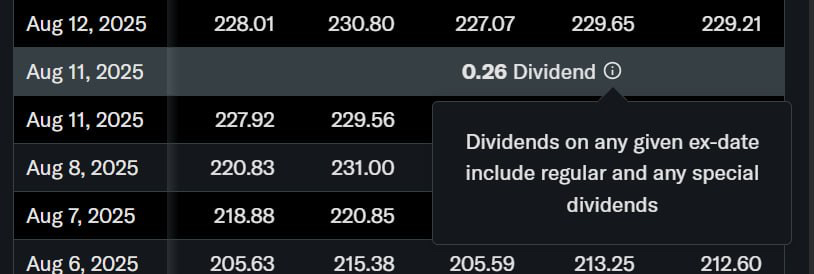

И наконец собираем наш датасет

In [ ]:
df_list = []
for i in table.text.split('\n'):
    spl = i.split()
    if 'Dividend' in spl or 'Stock' in spl:
        continue
    d = list(spl)[:3]
    d[0] = f'{d[0]} {d[1]} {d[2]}'
    d.pop(1)
    d.pop(1)

    val = list(map(float, spl[3:-1]))
    volume = float(spl[-1].replace(',', ''))

    d.extend(val)
    d.append(volume)

    df_list.append(d)

df_list

In [ ]:
df = pd.DataFrame(df_list, columns=cols)
df

Таким образом, мы сделали для компании Apple. Теперь соберем всё в цикл, пройдя по всем компаниям

Полный код со всеми компаниями ниже

In [ ]:
startdate = datetime(2021, 1, 1).timestamp()
enddate = datetime(2026, 4, 9).timestamp()

df_list = []

for ticker in ['AAPL', 'XOM', 'TSLA', 'WMT', 'PFE', 'NFLX', 'JPM', 'CAT']:
    service = Service(ChromeDriverManager().install())
    driver = webdriver.Chrome(service=service)

    url = f'https://finance.yahoo.com/quote/{ticker}/history/?period1={startdate}&period2={enddate}'
    driver.get(url)

    try:
        accept = WebDriverWait(driver, 3).until(EC.element_to_be_clickable((By.XPATH, "//button[contains(text(), 'Accept all')]")))
        accept.click()
    except:
        pass

    if ticker == 'AAPL':
        headers = driver.find_element(By.XPATH, '//*[@id="main-content-wrapper"]/div[1]/div[3]/table/thead/tr')
        t = headers.text.split('\n')
        cols = t[0].split() + t[1:]
        cols.insert(0, 'ticker')

    table = driver.find_element(By.XPATH, '//*[@id="main-content-wrapper"]/div[1]/div[3]/table/tbody')

    for i in table.text.split('\n'):
        spl = i.split()

        if 'Dividend' in spl  or 'Stock' in spl:
            continue

        d = list(spl)[:3]
        d[0] = f'{d[0]} {d[1]} {d[2]}'
        d.pop(1)
        d.pop(1)

        val = list(map(float, spl[3:-1]))
        volume = float(spl[-1].replace(',', ''))

        d.extend(val)
        d.append(volume)
        d.insert(0, ticker)
        df_list.append(d)

    driver.quit()
    time.sleep(1)


df = pd.DataFrame(df_list, columns=cols)

df
driver.quit()

In [ ]:
df.to_csv('quotes_all.csv')

Сохраним датасет в `quotes_all.csv`